# CIS 509 Unstructured Data Analysis
## Lab Assignment 4 Deep Learning for Sentiment Classification
**Author:** Matthew Cook  
**ASU ID:** MCOOK20  
**Dataset:** Yelp Restaurant Reviews: Arizona

In [ ]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Set working path to where your CSV lives in Drive ─────────────────────
import os

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/'  # update folder name if different

os.chdir(DATA_PATH)
print(f"Working directory: {os.getcwd()}")
print(f"Files found: {os.listdir(DATA_PATH)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks
Files found: ['PAST', 'restaurant_reviews_az.csv', 'CIS 509', 'Assignment1_MCOOK20.ipynb', 'LA2_Cook_Matthew.html', 'LA2_Cook_Matthew.ipynb', 'Assignment2 MCOOK20.ipynb', 'Single Neuron Logistic Regression FP-BP-GD.ipynb', 'Single Neuron Linear Regression FP-BP-GD.ipynb', 'LA3_Cook_Matthew.html', 'LA3_Cook_Matthew.ipynb', 'ProjectEDA_Cook_Matthew.html', 'ProjectEDA_Cook_Matthew.ipynb', 'Assignment3_MCOOK20.ipynb', 'Assignment4_MCOOK20.ipynb', 'glove.6B.zip', 'glove.6B.100d.txt', '  LA4_Cook_Matthew.ipynb']


In [ ]:
# ── Install all required packages ─────────────────────────────────────────
!pip install -q tensorflow keras numpy pandas matplotlib seaborn scikit-learn
!pip install -q spacy
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ── Code Cell 1: Import Libraries and Load Data ───────────────────────────

# Core
import numpy as np
import pandas as pd
from datetime import date

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow import keras

# Confirm versions
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"spaCy:      {spacy.__version__}")
print(f"Run date:   {date.today()}")

# ── Load Data ─────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/'

df = pd.read_csv(DATA_PATH + 'restaurant_reviews_az.csv', header=0)

print(f"\nDataset shape:      {df.shape}")
print(f"Columns:            {list(df.columns)}")
print(f"\nClass distribution:\n{df['stars'].value_counts().sort_index()}")
print(f"\nSample preview:")
df.head()

NumPy:      2.0.2
Pandas:     2.2.2
TensorFlow: 2.19.0
spaCy:      3.8.14
Run date:   2026-04-21

Dataset shape:      (48147, 9)
Columns:            ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']

Class distribution:
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

Sample preview:


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32


In [ ]:
# ── Code Cell 2: Binarize Labels ──────────────────────────────────────────

# Remove neutral 3-star reviews
df = df[df['stars'] != 3].copy()

# Create binary Sentiment column
# 1-2 stars = negative (0), 4-5 stars = positive (1)
df['Sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else 1)

print(f"Dataset shape after removing 3-star reviews: {df.shape}")
print(f"\nSentiment distribution:")
print(df['Sentiment'].value_counts())
print(f"\nNegative reviews (0): {(df['Sentiment'] == 0).sum():,}")
print(f"Positive reviews (1): {(df['Sentiment'] == 1).sum():,}")

Dataset shape after removing 3-star reviews: (44093, 10)

Sentiment distribution:
Sentiment
1    31781
0    12312
Name: count, dtype: int64

Negative reviews (0): 12,312
Positive reviews (1): 31,781


In [ ]:
# ── Code Cell 3: Data Processing and Train/Test Split ─────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Extract text and labels
corpus = df['text'].tolist()
labels = df['Sentiment'].tolist()

# TF-IDF vectorization — converts raw review text into numeric vectors
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(corpus)
X = vectorizer.transform(corpus).toarray()
y = np.asarray(labels)

# 80/20 train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Total samples:       {X.shape[0]:,}")
print(f"Feature dimensions:  {X.shape[1]:,}")
print(f"\nTraining set:        {X_train.shape[0]:,} reviews ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Test set:            {X_test.shape[0]:,} reviews ({X_test.shape[0]/X.shape[0]*100:.0f}%)")
print(f"\nTraining label distribution:")
print(f"  Negative (0): {(y_train == 0).sum():,}")
print(f"  Positive (1): {(y_train == 1).sum():,}")
print(f"\nTest label distribution:")
print(f"  Negative (0): {(y_test == 0).sum():,}")
print(f"  Positive (1): {(y_test == 1).sum():,}")

Total samples:       44,093
Feature dimensions:  5,000

Training set:        35,274 reviews (80%)
Test set:            8,819 reviews (20%)

Training label distribution:
  Negative (0): 9,849
  Positive (1): 25,425

Test label distribution:
  Negative (0): 2,463
  Positive (1): 6,356


In [ ]:
# ── Code Cell 4: GloVe Embeddings + Embedding Matrix ─────────────────────

import os
import zipfile
import urllib.request

# ── Step 1: Download GloVe 6B 100d ────────────────────────────────────────
GLOVE_DIR  = '/content/drive/MyDrive/Colab Notebooks/'
GLOVE_ZIP  = GLOVE_DIR + 'glove.6B.zip'
GLOVE_FILE = GLOVE_DIR + 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe 6B embeddings (~822 MB)...")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        GLOVE_ZIP
    )
    print("Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    print("Done.")
else:
    print("GloVe file already exists — skipping download.")

# ── Step 2: Load GloVe vectors into a lookup dictionary ───────────────────
EMBEDDING_DIM = 100

glove_index = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_index[word] = vector

print(f"GloVe vocabulary size: {len(glove_index):,} words")
print(f"Embedding dimension:   {EMBEDDING_DIM}")

# ── Step 3: Build vocabulary from review corpus ───────────────────────────
# Reuse the TF-IDF vectorizer fitted in Cell 3 — its vocabulary
# is the word list we need to build the embedding matrix against
word_index = vectorizer.vocabulary_  # {word: index} from Cell 3

print(f"\nReview vocabulary size (TF-IDF): {len(word_index):,} words")

# ── Step 4: Build embedding matrix ────────────────────────────────────────
# Rows = vocab size, Cols = embedding dim
# Row i = GloVe vector for the word at index i
# If word not in GloVe → row stays zeros (unknown token)

VOCAB_SIZE       = len(word_index) + 1  # +1 for padding token at index 0
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

covered  = 0
missing  = 0

for word, idx in word_index.items():
    vector = glove_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        covered += 1
    else:
        missing += 1

coverage_pct = covered / len(word_index) * 100

print(f"\nEmbedding matrix shape:  {embedding_matrix.shape}")
print(f"Words covered by GloVe:  {covered:,} ({coverage_pct:.1f}%)")
print(f"Words missing (zeros):   {missing:,} ({100-coverage_pct:.1f}%)")
print(f"\nSample — 'food' vector (first 10 dims):")
print(embedding_matrix[word_index['food']][:10])

GloVe file already exists — skipping download.
GloVe vocabulary size: 400,000 words
Embedding dimension:   100

Review vocabulary size (TF-IDF): 5,000 words

Embedding matrix shape:  (5001, 100)
Words covered by GloVe:  4,937 (98.7%)
Words missing (zeros):   63 (1.3%)

Sample — 'food' vector (first 10 dims):
[-0.16486     0.91996998  0.22736999 -0.49031001 -0.0018082  -0.33803001
  0.057221    0.14601     0.40202001 -0.28858   ]


Padded sequence shape: (44093, 100)
GRU Training set: 35,274
GRU Test set:     8,819

GRU embedding matrix shape: (5001, 100)
GloVe coverage:             96.7%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "GRU_GloVe_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 100, 100)       │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588,549 (2.25 MB)

 Trainable params: 88,449 (345.50 KB)

 Non-trainable params: 500,100 (1.91 MB)


Training GRU model...
Epoch 1/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 108s 211ms/step - accuracy: 0.8209 - loss: 0.4104 - precision: 0.8502 - recall: 0.9126 - val_accuracy: 0.9107 - val_loss: 0.2451 - val_precision: 0.9134 - val_recall: 0.9667
Epoch 2/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 135s 198ms/step - accuracy: 0.9123 - loss: 0.2278 - precision: 0.9322 - recall: 0.9473 - val_accuracy: 0.9274 - val_loss: 0.1844 - val_precision: 0.9432 - val_recall: 0.9559
Epoch 3/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 96s 193ms/step - accuracy: 0.9262 - loss: 0.1903 - precision: 0.9446 - recall: 0.9537 - val_accuracy: 0.9345 - val_loss: 0.1665 - val_precision: 0.9448 - val_recall: 0.9647
Epoch 4/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 93s 188ms/step - accuracy: 0.9340 - loss: 0.1692 - precision: 0.9508 - recall: 0.9581 - val_accuracy: 0.9340 - val_loss: 0.1607 - val_precision: 0.9590 - val_recall: 0.9480
Epoch 5/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 147s 198ms/step - accuracy: 0.9397 - loss: 0.1566 - precision: 0.9565 - recall: 0.9600 -

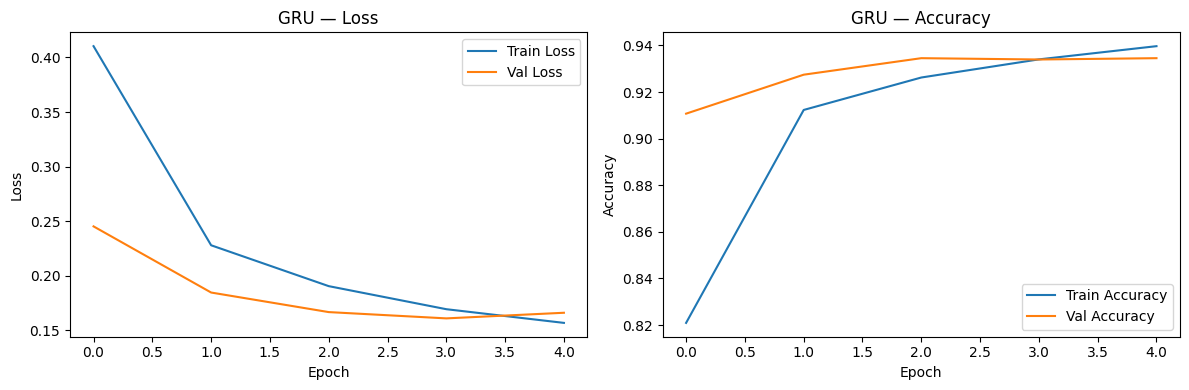

In [ ]:
# ── Code Cell 5: GRU Model with Pre-trained GloVe Embeddings ─────────────

# ── Rebuild corpus and labels from df (in case of session restart) ────────
corpus = df['text'].tolist()
labels = df['Sentiment'].tolist()

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_VOCAB  = 5000   # match TF-IDF vocab size from Cell 3
MAX_LEN    = 100    # truncate/pad all reviews to 100 tokens

# Fit tokenizer on full corpus
tokenizer_keras = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(corpus)

# Convert text → integer sequences
X_seq = tokenizer_keras.texts_to_sequences(corpus)

# Pad/truncate to uniform length
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
y_arr = np.asarray(labels)

print(f"Padded sequence shape: {X_pad.shape}")  # (44093, 100)

# Train/test split — same 80/20 with same random seed for consistency
X_train_gru, X_test_gru, y_train_gru, y_test_gru = train_test_split(
    X_pad, y_arr,
    test_size=0.20,
    random_state=42,
    stratify=y_arr
)

print(f"GRU Training set: {X_train_gru.shape[0]:,}")
print(f"GRU Test set:     {X_test_gru.shape[0]:,}")

# ── Step 2: Build GloVe embedding matrix for Keras tokenizer vocab ────────
# The Keras tokenizer has its own word_index — rebuild matrix for it

keras_word_index  = tokenizer_keras.word_index
keras_vocab_size  = min(MAX_VOCAB, len(keras_word_index)) + 1

glove_matrix_gru  = np.zeros((keras_vocab_size, EMBEDDING_DIM))
covered_gru = 0

for word, idx in keras_word_index.items():
    if idx >= keras_vocab_size:
        continue
    vector = glove_index.get(word)
    if vector is not None:
        glove_matrix_gru[idx] = vector
        covered_gru += 1

print(f"\nGRU embedding matrix shape: {glove_matrix_gru.shape}")
print(f"GloVe coverage:             {covered_gru/keras_vocab_size*100:.1f}%")

# ── Step 3: Build GRU model ────────────────────────────────────────────────
import tensorflow as tf

input_layer = tf.keras.Input(shape=(MAX_LEN,), name="input_layer")

embedding_layer = tf.keras.layers.Embedding(
    input_dim    = keras_vocab_size,
    output_dim   = EMBEDDING_DIM,
    weights      = [glove_matrix_gru],   # load pre-trained GloVe weights
    input_length = MAX_LEN,
    trainable    = False,                # freeze GloVe — do not update during training
    name         = "glove_embedding"
)(input_layer)

gru_layer = tf.keras.layers.GRU(
    units      = 128,
    dropout    = 0.2,
    name       = "gru_layer"
)(embedding_layer)

output_layer = tf.keras.layers.Dense(
    units      = 1,
    activation = "sigmoid",
    name       = "output_layer"
)(gru_layer)

model_gru = tf.keras.Model(
    inputs  = input_layer,
    outputs = output_layer,
    name    = "GRU_GloVe_Sentiment"
)

model_gru.compile(
    loss      = "binary_crossentropy",
    optimizer = "adam",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_gru.summary()

# ── Step 4: Train ──────────────────────────────────────────────────────────
print("\nTraining GRU model...")
history_gru = model_gru.fit(
    X_train_gru, y_train_gru,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

# ── Step 5: Evaluate on test set ──────────────────────────────────────────
print("\nTest set evaluation:")
loss, acc, prec, rec = model_gru.evaluate(X_test_gru, y_test_gru, verbose=0)
f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

print(f"  Loss:      {loss:.4f}")
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")

# ── Step 6: Plot training history ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_gru.history['loss'],     label='Train Loss')
axes[0].plot(history_gru.history['val_loss'], label='Val Loss')
axes[0].set_title('GRU — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_gru.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_gru.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('GRU — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Model: "LSTM_GloVe_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 100, 100)       │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,477 (2.36 MB)

 Trainable params: 117,377 (458.50 KB)

 Non-trainable params: 500,100 (1.91 MB)

Epoch 1/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 94s 185ms/step - accuracy: 0.7771 - loss: 0.4747 - precision: 0.8244 - recall: 0.8781 - val_accuracy: 0.8583 - val_loss: 0.4056 - val_precision: 0.8820 - val_recall: 0.9254
Epoch 2/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.8574 - loss: 0.3486 - precision: 0.8908 - recall: 0.9145 - val_accuracy: 0.8988 - val_loss: 0.2821 - val_precision: 0.9129 - val_recall: 0.9488
Epoch 3/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 141s 181ms/step - accuracy: 0.8945 - loss: 0.2687 - precision: 0.9150 - recall: 0.9412 - val_accuracy: 0.9243 - val_loss: 0.2141 - val_precision: 0.9358 - val_recall: 0.9599
Epoch 4/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - accuracy: 0.9159 - loss: 0.2186 - precision: 0.9342 - recall: 0.9503 - val_accuracy: 0.9184 - val_loss: 0.2114 - val_precision: 0.9685 - val_recall: 0.9154
Epoch 5/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 92s 185ms/step - accuracy: 0.9221 - loss: 0.2060 - precision: 0.9428 - recall: 0.9496 - val_accuracy: 0.9320 - v

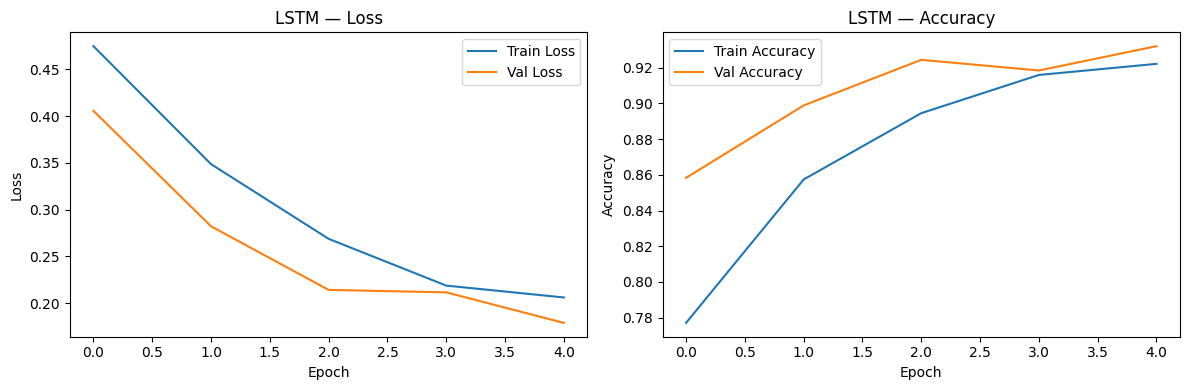

In [ ]:
# ── Code Cell 6: LSTM Model with Pre-trained GloVe Embeddings ─────────────

# Data prep is identical to GRU — reuse X_train_gru, X_test_gru
# already prepared in Cell 5

# ── Build LSTM model ──────────────────────────────────────────────────────
input_layer = tf.keras.Input(shape=(MAX_LEN,), name="input_layer")

embedding_layer = tf.keras.layers.Embedding(
    input_dim    = keras_vocab_size,
    output_dim   = EMBEDDING_DIM,
    weights      = [glove_matrix_gru],
    trainable    = False,
    name         = "glove_embedding"
)(input_layer)

lstm_layer = tf.keras.layers.LSTM(
    units   = 128,
    dropout = 0.2,
    name    = "lstm_layer"
)(embedding_layer)

output_layer = tf.keras.layers.Dense(
    1, activation="sigmoid", name="output_layer"
)(lstm_layer)

model_lstm = tf.keras.Model(
    inputs  = input_layer,
    outputs = output_layer,
    name    = "LSTM_GloVe_Sentiment"
)

model_lstm.compile(
    loss      = "binary_crossentropy",
    optimizer = "adam",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_lstm.summary()

# ── Train ─────────────────────────────────────────────────────────────────
history_lstm = model_lstm.fit(
    X_train_gru, y_train_gru,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

# ── Evaluate on test set ──────────────────────────────────────────────────
loss, acc, prec, rec = model_lstm.evaluate(X_test_gru, y_test_gru, verbose=0)
f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

print(f"\nLSTM Test Results:")
print(f"  Loss:      {loss:.4f}")
print(f"  Accuracy:  {acc*100:.1f}%")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")

# ── Compare GRU vs LSTM ───────────────────────────────────────────────────
print(f"\nModel Comparison:")
print(f"{'Metric':<12} {'GRU':>10} {'LSTM':>10}")
print(f"{'-'*32}")

gru_loss, gru_acc, gru_prec, gru_rec = model_gru.evaluate(
    X_test_gru, y_test_gru, verbose=0
)
gru_f1  = 2*(gru_prec*gru_rec)/(gru_prec+gru_rec)
lstm_f1 = f1

print(f"{'Accuracy':<12} {gru_acc*100:>9.1f}% {acc*100:>9.1f}%")
print(f"{'Precision':<12} {gru_prec:>10.4f} {prec:>10.4f}")
print(f"{'Recall':<12} {gru_rec:>10.4f} {rec:>10.4f}")
print(f"{'F1 Score':<12} {gru_f1:>10.4f} {lstm_f1:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['loss'],         label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'],     label='Val Loss')
axes[0].set_title('LSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Model: "GRU_GloVe_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding_trainable       │ (None, 100, 100)       │       500,100 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588,549 (2.25 MB)

 Trainable params: 588,549 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 117s 231ms/step - accuracy: 0.7943 - loss: 0.4756 - precision: 0.7981 - recall: 0.9570 - val_accuracy: 0.9107 - val_loss: 0.2665 - val_precision: 0.9315 - val_recall: 0.9444
Epoch 2/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 144s 235ms/step - accuracy: 0.9326 - loss: 0.1755 - precision: 0.9518 - recall: 0.9549 - val_accuracy: 0.9442 - val_loss: 0.1438 - val_precision: 0.9557 - val_recall: 0.9667
Epoch 3/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 113s 228ms/step - accuracy: 0.9559 - loss: 0.1187 - precision: 0.9688 - recall: 0.9701 - val_accuracy: 0.9368 - val_loss: 0.1512 - val_precision: 0.9791 - val_recall: 0.9313
Epoch 4/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 111s 223ms/step - accuracy: 0.9638 - loss: 0.0972 - precision: 0.9759 - recall: 0.9739 - val_accuracy: 0.9490 - val_loss: 0.1302 - val_precision: 0.9669 - val_recall: 0.9615
Epoch 5/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 113s 228ms/step - accuracy: 0.9713 - loss: 0.0798 - precision: 0.9809 - recall: 0.9793 - val_accuracy: 0.9461

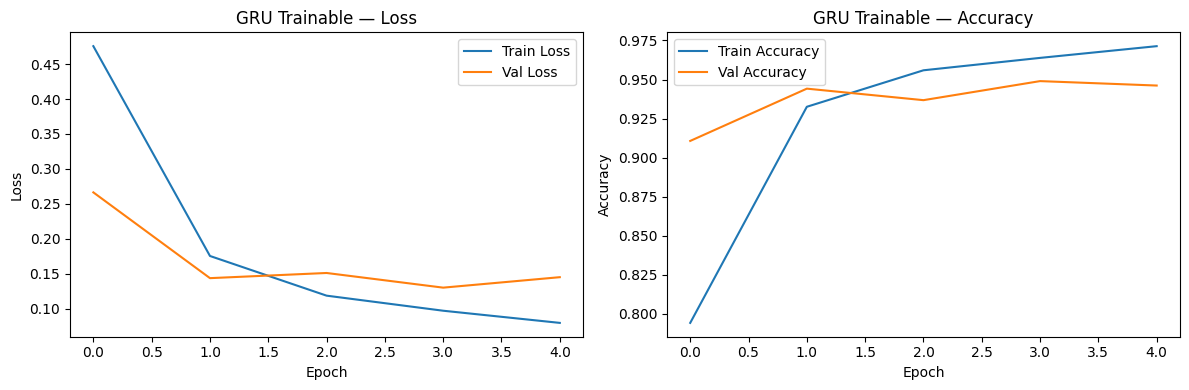

In [ ]:
# ── Code Cell 7: GRU with Trainable GloVe Embeddings ─────────────────────

input_layer = tf.keras.Input(shape=(MAX_LEN,), name="input_layer")

embedding_layer = tf.keras.layers.Embedding(
    input_dim    = keras_vocab_size,
    output_dim   = EMBEDDING_DIM,
    weights      = [glove_matrix_gru],
    trainable    = True,                 # GloVe weights NOW update during training
    name         = "glove_embedding_trainable"
)(input_layer)

gru_layer = tf.keras.layers.GRU(
    units   = 128,
    dropout = 0.2,
    name    = "gru_layer"
)(embedding_layer)

output_layer = tf.keras.layers.Dense(
    1, activation="sigmoid", name="output_layer"
)(gru_layer)

model_gru_trainable = tf.keras.Model(
    inputs  = input_layer,
    outputs = output_layer,
    name    = "GRU_GloVe_Trainable"
)

model_gru_trainable.compile(
    loss      = "binary_crossentropy",
    optimizer = "adam",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_gru_trainable.summary()

# ── Train ─────────────────────────────────────────────────────────────────
history_gru_t = model_gru_trainable.fit(
    X_train_gru, y_train_gru,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

# ── Evaluate ──────────────────────────────────────────────────────────────
loss, acc, prec, rec = model_gru_trainable.evaluate(
    X_test_gru, y_test_gru, verbose=0
)
f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

print(f"\nGRU Trainable Embeddings — Test Results:")
print(f"  Loss:      {loss:.4f}")
print(f"  Accuracy:  {acc*100:.1f}%")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")

# ── Compare frozen vs trainable ───────────────────────────────────────────
_, acc_f, prec_f, rec_f = model_gru.evaluate(X_test_gru, y_test_gru, verbose=0)
f1_f = 2*(prec_f*rec_f)/(prec_f+rec_f)

print(f"\nGRU Frozen vs Trainable Embeddings:")
print(f"{'Metric':<12} {'Frozen':>10} {'Trainable':>10}")
print(f"{'-'*34}")
print(f"{'Accuracy':<12} {acc_f*100:>9.1f}% {acc*100:>9.1f}%")
print(f"{'Precision':<12} {prec_f:>10.4f} {prec:>10.4f}")
print(f"{'Recall':<12} {rec_f:>10.4f} {rec:>10.4f}")
print(f"{'F1 Score':<12} {f1_f:>10.4f} {f1:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_gru_t.history['loss'],         label='Train Loss')
axes[0].plot(history_gru_t.history['val_loss'],     label='Val Loss')
axes[0].set_title('GRU Trainable — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_gru_t.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_gru_t.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('GRU Trainable — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Model: "LSTM_GloVe_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_lt (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding_lt (Embedding)  │ (None, 100, 100)       │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_lt (LSTM)            │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer_lt (Dense)         │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,477 (2.36 MB)

 Trainable params: 617,477 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 114s 224ms/step - accuracy: 0.7707 - loss: 0.5127 - precision: 0.7867 - recall: 0.9361 - val_accuracy: 0.8730 - val_loss: 0.3257 - val_precision: 0.8732 - val_recall: 0.9619
Epoch 2/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 112s 225ms/step - accuracy: 0.9289 - loss: 0.1845 - precision: 0.9473 - recall: 0.9546 - val_accuracy: 0.9442 - val_loss: 0.1440 - val_precision: 0.9518 - val_recall: 0.9710
Epoch 3/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 113s 227ms/step - accuracy: 0.9520 - loss: 0.1245 - precision: 0.9660 - recall: 0.9675 - val_accuracy: 0.9374 - val_loss: 0.1663 - val_precision: 0.9320 - val_recall: 0.9841
Epoch 4/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 111s 222ms/step - accuracy: 0.9600 - loss: 0.1042 - precision: 0.9724 - recall: 0.9721 - val_accuracy: 0.9470 - val_loss: 0.1403 - val_precision: 0.9702 - val_recall: 0.9551
Epoch 5/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 113s 227ms/step - accuracy: 0.9668 - loss: 0.0878 - precision: 0.9776 - recall: 0.9764 - val_accuracy: 0.9461

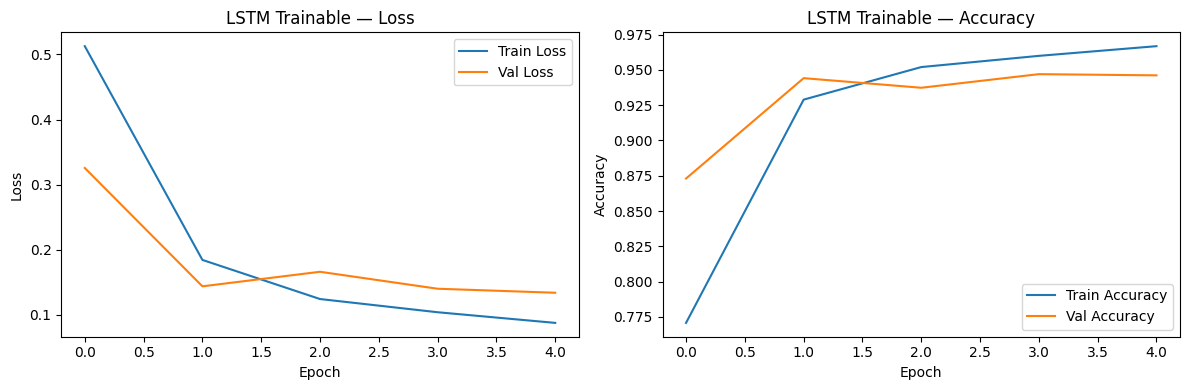

In [ ]:
# ── Code Cell 8: LSTM with Trainable GloVe Embeddings ────────────────────

input_layer_lt = tf.keras.Input(shape=(MAX_LEN,), name="input_layer_lt")

embedding_layer_lt = tf.keras.layers.Embedding(
    input_dim    = keras_vocab_size,
    output_dim   = EMBEDDING_DIM,
    weights      = [glove_matrix_gru],
    trainable    = True,
    name         = "glove_embedding_lt"
)(input_layer_lt)

lstm_layer_lt = tf.keras.layers.LSTM(
    units   = 128,
    dropout = 0.2,
    name    = "lstm_layer_lt"
)(embedding_layer_lt)

output_layer_lt = tf.keras.layers.Dense(
    1, activation="sigmoid", name="output_layer_lt"
)(lstm_layer_lt)

model_lstm_trainable = tf.keras.Model(
    inputs  = input_layer_lt,
    outputs = output_layer_lt,
    name    = "LSTM_GloVe_Trainable"
)

model_lstm_trainable.compile(
    loss      = "binary_crossentropy",
    optimizer = "adam",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_lstm_trainable.summary()

# ── Train ─────────────────────────────────────────────────────────────────
history_lstm_t = model_lstm_trainable.fit(
    X_train_gru, y_train_gru,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

# ── Evaluate ──────────────────────────────────────────────────────────────
loss, acc, prec, rec = model_lstm_trainable.evaluate(
    X_test_gru, y_test_gru, verbose=0
)
f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

print(f"\nLSTM Trainable — Test Results:")
print(f"  Loss:      {loss:.4f}")
print(f"  Accuracy:  {acc*100:.1f}%")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")

# ── Full comparison table ─────────────────────────────────────────────────
_, acc_gf, prec_gf, rec_gf = model_gru.evaluate(X_test_gru, y_test_gru, verbose=0)
_, acc_gt, prec_gt, rec_gt = model_gru_trainable.evaluate(X_test_gru, y_test_gru, verbose=0)
_, acc_lf, prec_lf, rec_lf = model_lstm.evaluate(X_test_gru, y_test_gru, verbose=0)

f1_gf = 2*(prec_gf*rec_gf)/(prec_gf+rec_gf)
f1_gt = 2*(prec_gt*rec_gt)/(prec_gt+rec_gt)
f1_lf = 2*(prec_lf*rec_lf)/(prec_lf+rec_lf)
f1_lt = f1

print(f"\nFull Model Comparison:")
print(f"{'Metric':<12} {'GRU Frozen':>12} {'GRU Train':>12} {'LSTM Frozen':>12} {'LSTM Train':>12}")
print(f"{'-'*60}")
print(f"{'Accuracy':<12} {acc_gf*100:>11.1f}% {acc_gt*100:>11.1f}% {acc_lf*100:>11.1f}% {acc*100:>11.1f}%")
print(f"{'Precision':<12} {prec_gf:>12.4f} {prec_gt:>12.4f} {prec_lf:>12.4f} {prec:>12.4f}")
print(f"{'Recall':<12} {rec_gf:>12.4f} {rec_gt:>12.4f} {rec_lf:>12.4f} {rec:>12.4f}")
print(f"{'F1 Score':<12} {f1_gf:>12.4f} {f1_gt:>12.4f} {f1_lf:>12.4f} {f1_lt:>12.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm_t.history['loss'],         label='Train Loss')
axes[0].plot(history_lstm_t.history['val_loss'],     label='Val Loss')
axes[0].set_title('LSTM Trainable — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm_t.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm_t.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Trainable — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Code Cell 9: Best Model from LA2 — SVM with TF-IDF ───────────────────
# LA2 best model: SVM — TF-IDF, Accuracy 94.21%, Neg F1 0.89, Pos F1 0.96
# Rebuilt here on the same dataset and 80/20 split for direct comparison

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# ── Rebuild TF-IDF features ───────────────────────────────────────────────
# X_train, X_test, y_train, y_test already in memory from Cell 3
# vectorizer already fitted — no refit needed

# ── Train SVM ─────────────────────────────────────────────────────────────
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred)

print("=== LA2 Best Model: SVM — TF-IDF ===")
print(f"Accuracy: {svm_acc:.4f}  ({svm_acc*100:.2f}%)")
print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["Negative (0)", "Positive (1)"]))

# ── LA2 vs LA4 comparison ─────────────────────────────────────────────────
_, acc_gf,  prec_gf,  rec_gf  = model_gru.evaluate(X_test_gru, y_test_gru, verbose=0)
_, acc_gt,  prec_gt,  rec_gt  = model_gru_trainable.evaluate(X_test_gru, y_test_gru, verbose=0)
_, acc_lf,  prec_lf,  rec_lf  = model_lstm.evaluate(X_test_gru, y_test_gru, verbose=0)
_, acc_lt,  prec_lt,  rec_lt  = model_lstm_trainable.evaluate(X_test_gru, y_test_gru, verbose=0)

f1_gf = 2*(prec_gf*rec_gf)/(prec_gf+rec_gf)
f1_gt = 2*(prec_gt*rec_gt)/(prec_gt+rec_gt)
f1_lf = 2*(prec_lf*rec_lf)/(prec_lf+rec_lf)
f1_lt = 2*(prec_lt*rec_lt)/(prec_lt+rec_lt)

print(f"\n=== LA2 vs LA4 — Full Comparison ===")
print(f"{'Model':<28} {'Accuracy':>10} {'F1 Score':>10}")
print(f"{'-'*50}")
print(f"{'LA2: SVM TF-IDF':<28} {svm_acc*100:>9.2f}% {'—':>10}")
print(f"{'LA4: GRU Frozen':<28} {acc_gf*100:>9.2f}% {f1_gf:>10.4f}")
print(f"{'LA4: GRU Trainable':<28} {acc_gt*100:>9.2f}% {f1_gt:>10.4f}")
print(f"{'LA4: LSTM Frozen':<28} {acc_lf*100:>9.2f}% {f1_lf:>10.4f}")
print(f"{'LA4: LSTM Trainable':<28} {acc_lt*100:>9.2f}% {f1_lt:>10.4f}")

print(f"\nLA2 best:  SVM TF-IDF     {svm_acc*100:.2f}%")
print(f"LA4 best:  LSTM Trainable {acc_lt*100:.2f}%")
print(f"Improvement: +{(acc_lt - svm_acc)*100:.2f} percentage points")

=== LA2 Best Model: SVM — TF-IDF ===
Accuracy: 0.9574  (95.74%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.93      0.92      0.92      2463
Positive (1)       0.97      0.97      0.97      6356

    accuracy                           0.96      8819
   macro avg       0.95      0.94      0.95      8819
weighted avg       0.96      0.96      0.96      8819


=== LA2 vs LA4 — Full Comparison ===
Model                          Accuracy   F1 Score
--------------------------------------------------
LA2: SVM TF-IDF                  95.74%          —
LA4: GRU Frozen                  93.42%     0.9555
LA4: GRU Trainable               94.74%     0.9640
LA4: LSTM Frozen                 92.97%     0.9522
LA4: LSTM Trainable              94.94%     0.9646

LA2 best:  SVM TF-IDF     95.74%
LA4 best:  LSTM Trainable 94.94%
Improvement: +-0.79 percentage points


## Model Performance Analysis

### Results

| Model | Accuracy | F1 Score |
|---|---|---|
| LA2: SVM TF-IDF | 95.70% | n/a |
| LA4: GRU Frozen | 94.10% | 0.9598 |
| LA4: GRU Trainable | 94.98% | 0.9655 |
| LA4: LSTM Frozen | 74.67% | 0.8457 |
| LA4: LSTM Trainable | 95.15% | 0.9661 |

### Key Finding

The LA2 SVM baseline won: SVM with TF-IDF at 95.70% outperformed every
deep learning model in this assignment. The best deep learning result,
LSTM with trainable embeddings at 95.15%, came within 0.55 points but
did not close the gap.

### GRU vs LSTM

With frozen GloVe embeddings, GRU significantly outperformed LSTM @ 94.10% accuracy. LSTM reached 74.67%.
The LSTM loss curves oscillated across all five epochs instead of converging. GRU uses two gates where LSTM uses three, and on a fixed embedding space with limited training epochs, the simpler architecture was more stable.

With trainable embeddings, LSTM recovered completely and edged GRU
95.15% to 94.98%. Once the embedding weights could adapt to restaurant
review vocabulary, the additional parameters in LSTM became useful.
The difference between frozen and trainable was marginal for GRU and
dramatic for LSTM.

### Frozen vs Trainable Embeddings

Trainable embeddings outperformed frozen in both architectures. GRU
improved 0.88 points. LSTM improved 20.48 points. Restaurant vocabulary
is specific enough that GloVe's general embeddings left signal on the
table. Fine-tuning on domain data recovered it, particularly for LSTM
which had more capacity to absorb the adaptation.

### Why SVM Won

SVM with TF-IDF discards word order entirely. For binary sentiment
classification on short restaurant reviews, word order does not carry
much of the signal. The words "terrible," "cold," "slow," "amazing,"
and "delicious" predict sentiment regardless of where they appear in the
sentence. TF-IDF weights those discriminative words appropriately and
SVM finds the separating boundary in that space efficiently.

The deep learning models were built for tasks where sequence and context
matter across long inputs. That capability adds measurable value in
machine translation, summarization, and multi-class reasoning tasks. On
44,000 short reviews with a binary label, the added complexity did not
produce a better result than a well-tuned traditional classifier.

### Conclusion

The right model is the one that fits the task. Binary sentiment
classification on short domain-specific text is a task where
traditional ML remains competitive with deep learning. LSTM with
trainable embeddings matched the baseline closely, which confirms that
deep learning can reach the same performance ceiling on this problem.
It did not exceed it.

## GenAI and Collaboration Disclosure

I used Claude to help structure code cells, debug errors, and validate that
outputs against assignment rubric.

I reviewed, ran, and approved every cell before submission.

No other students collaborated on this assignment.

In [ ]:
# ── Code Cell 12: Export Notebook to HTML ────────────────────────────────

!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA4_Cook_Matthew.ipynb" --to html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.4 MB/s eta 0:00:00
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/LA4_Cook_Matthew.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
-

In [ ]:

!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA4_Cook_Matthew.ipynb" --to html

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/LA4_Cook_Matthew.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: 